In [1]:
!pip uninstall -y scipy albumentations
!pip install scipy==1.10.1 albumentations==1.3.0 --no-cache-dir

Found existing installation: scipy 1.15.3
Uninstalling scipy-1.15.3:
  Successfully uninstalled scipy-1.15.3
Found existing installation: albumentations 2.0.8
Uninstalling albumentations-2.0.8:
  Successfully uninstalled albumentations-2.0.8
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 8.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of scikit-image to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.1/34.1 MB 250.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.5/123.5 kB 296.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 261.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 248.9 MB/s eta 0:00:00 0:00:01
  Attempting uninstall:

In [2]:
import os, cv2, numpy as np, matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pycocotools.coco import COCO

In [4]:
class UNet(nn.Module):
    def __init__(self, dropout=0.1):
        super(UNet, self).__init__()
        self.dropout_rate = dropout
        self.enc1 = self.conv_block(3, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = self.conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.bottleneck = self.conv_block(128, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = self.conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = self.conv_block(128, 64)
        self.out = nn.Conv2d(64, 1, kernel_size=1)

    def conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(self.dropout_rate)
        )

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)
        e2 = self.enc2(p1)
        p2 = self.pool2(e2)
        b = self.bottleneck(p2)
        u2 = self.up2(b)
        d2 = self.dec2(torch.cat([u2, e2], dim=1))
        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, e1], dim=1))
        return self.out(d1)

In [5]:
class COCOSegmentationDataset(Dataset):
    def __init__(self, coco, img_ids, img_dir, transform=None):
        self.coco = coco
        self.img_ids = img_ids
        self.img_dir = img_dir
        self.transform = transform

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.img_dir, img_info['file_name'])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
        for ann in anns:
            mask += self.coco.annToMask(ann)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image, mask = augmented['image'], augmented['mask']

        return image, mask.unsqueeze(0).float()

    def __len__(self):
        return len(self.img_ids)

In [6]:
transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(),
    ToTensorV2()
])

data_dir = "/kaggle/input/coco-2017-dataset/coco2017"
img_dir = os.path.join(data_dir, "train2017")
ann_file = os.path.join(data_dir, "annotations", "instances_train2017.json")

coco = COCO(ann_file)
img_ids = coco.getImgIds()[:500]  
dataset = COCOSegmentationDataset(coco, img_ids, img_dir, transform)
loader = DataLoader(dataset, batch_size=8, shuffle=True)

loading annotations into memory...
Done (t=24.27s)
creating index...
index created!


In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

for epoch in range(5):  
    model.train()
    total_loss = 0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        logits = model(images)
        loss = criterion(logits, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} Loss: {total_loss:.4f}")

torch.save(model.state_dict(), "unet_coco.pth")

Epoch 1 Loss: 35.0739
Epoch 2 Loss: 32.7602
Epoch 3 Loss: 32.5203
Epoch 4 Loss: 31.9951
Epoch 5 Loss: 31.8428


In [12]:
def denormalize(tensor, mean, std):
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor

In [13]:
def iou(pred, target, threshold=0.5):
    pred_bin = (pred > threshold).float()
    intersection = (pred_bin * target).sum(dim=(1,2,3))
    union = pred_bin.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) - intersection
    return ((intersection + 1e-6) / (union + 1e-6)).mean().item()

def dice(pred, target, threshold=0.5):
    pred_bin = (pred > threshold).float()
    intersection = (pred_bin * target).sum(dim=(1,2,3))
    return ((2 * intersection + 1e-6) / (pred_bin.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) + 1e-6)).mean().item()

In [14]:
def preprocess_image(img_path):
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (256, 256))
    transform = A.Compose([
        A.Normalize(),
        ToTensorV2()
    ])
    image = transform(image=image)['image']
    return image.unsqueeze(0)

def predict_mask(model, image_tensor, threshold=0.3):
    model.eval()
    with torch.no_grad():
        logits = model(image_tensor.to(device))
        probs = torch.sigmoid(logits)
        binary_mask = (probs > threshold).float()
    return binary_mask.squeeze().cpu().numpy()

In [18]:
def apply_mask(image_tensor, binary_mask):
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]

    image_tensor = denormalize(image_tensor.squeeze().cpu(), mean, std)
    image_np = image_tensor.permute(1, 2, 0).numpy()
    image_np = (np.clip(image_np, 0, 1) * 255).astype(np.uint8)

    binary_mask = (binary_mask > 0.5).astype(np.uint8)
    if np.mean(binary_mask) > 0.5:
        binary_mask = 1 - binary_mask

    masked = np.zeros_like(image_np)
    for c in range(3):
        masked[:, :, c] = image_np[:, :, c] * binary_mask

    return masked

def visualize(original_path, binary_mask, masked_img):
    original_img = cv2.imread(original_path)
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    original_img = cv2.resize(original_img, (mask.shape[1], mask.shape[0]))
    mask_vis = (binary_mask > 0.5).astype(np.uint8) * 255

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(original_img)
    axs[0].set_title("Original ")
    axs[1].imshow(mask_vis, cmap='gray')
    axs[1].set_title("Predicted Mask ")
    axs[2].imshow(masked_img)
    axs[2].set_title("Isolated Subject ")
    for ax in axs: ax.axis('off')
    plt.tight_layout()
    plt.show()

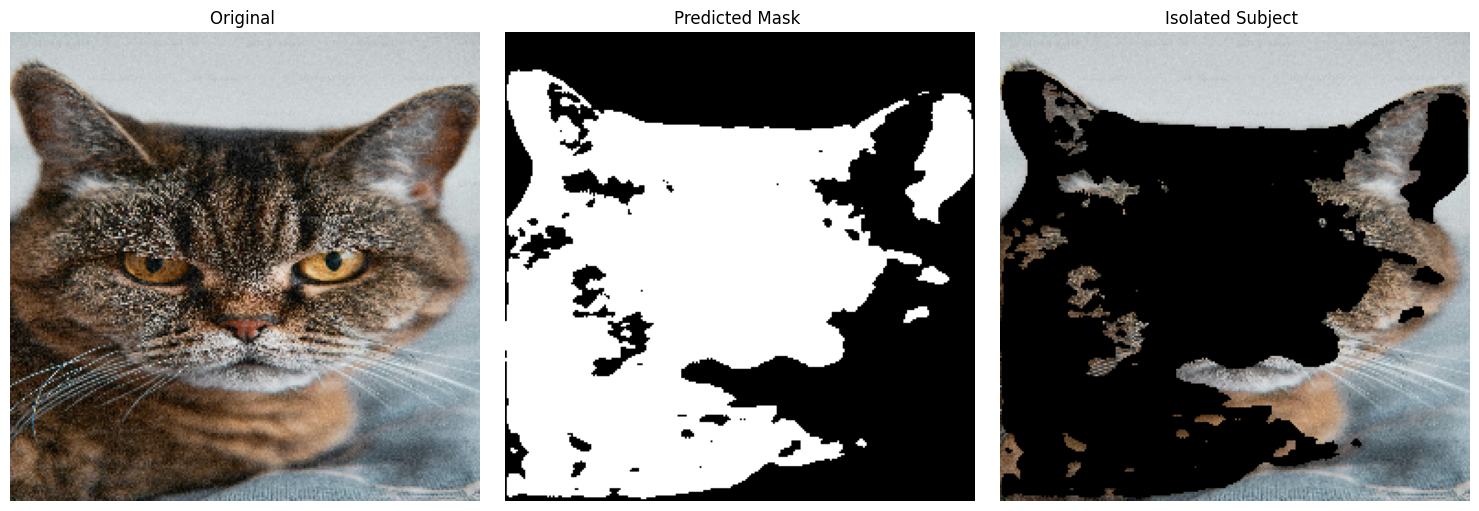

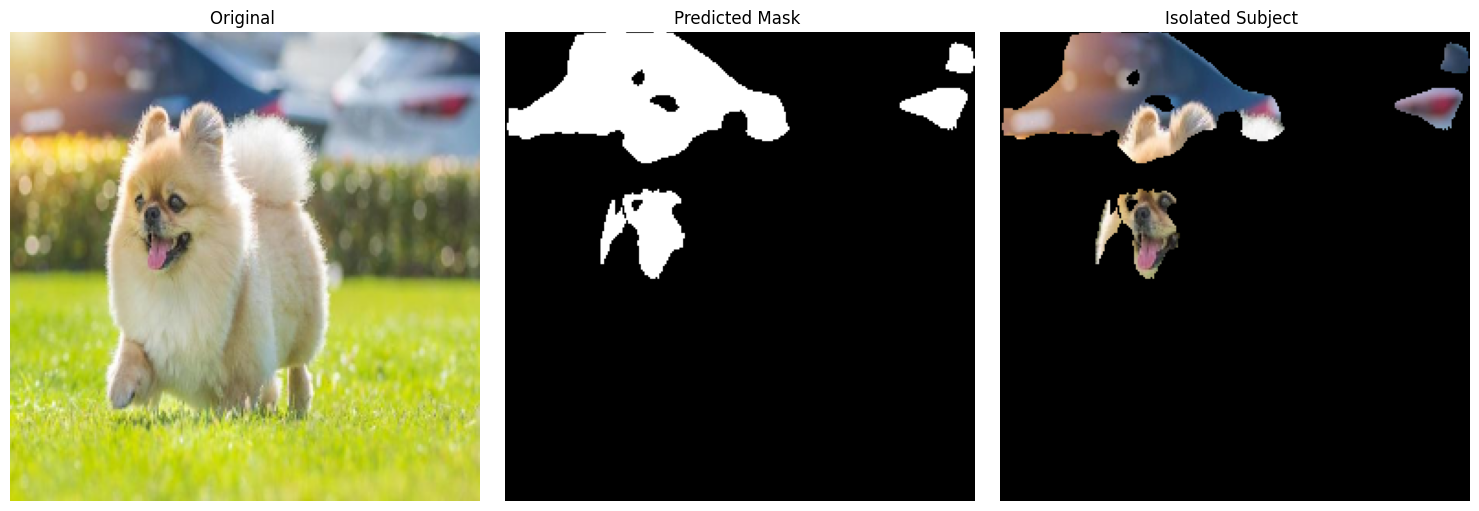

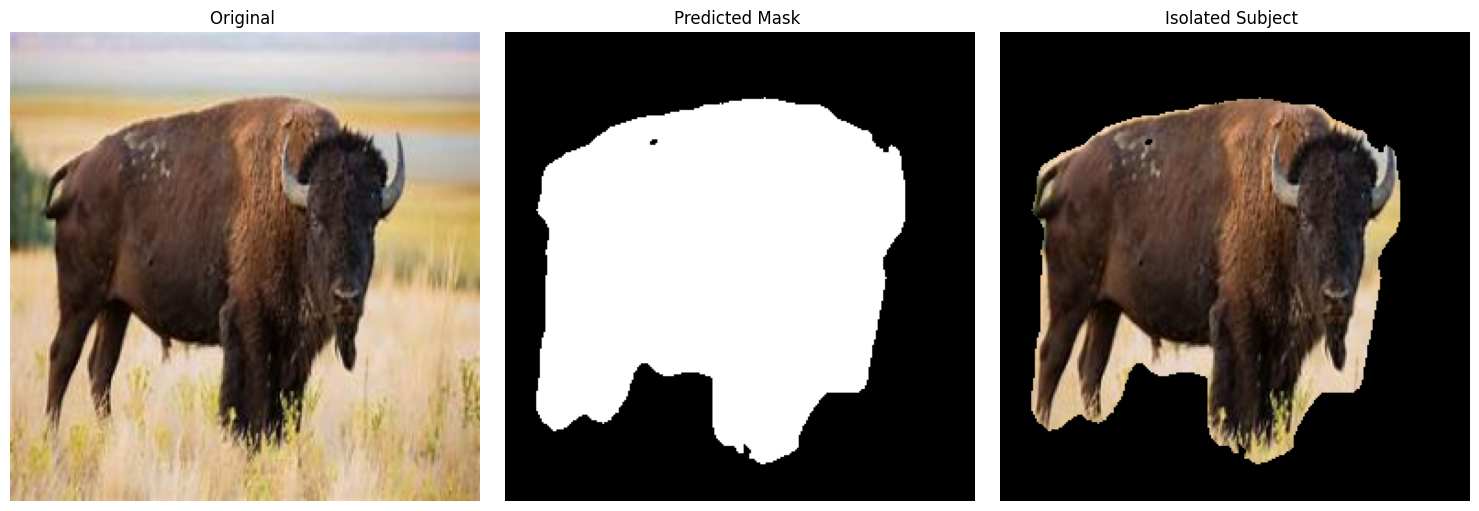

In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet().to(device)
model.load_state_dict(torch.load("unet_coco.pth"))  # Load your trained weights

unseen_paths = [
    '/kaggle/input/unseen-images/cat.jpg',
    '/kaggle/input/unseen-images/dog.jpg',
    '/kaggle/input/unseen-images/OIP.jpg'
]

for path in unseen_paths:
    img_tensor = preprocess_image(path)
    mask = predict_mask(model, img_tensor)
    masked_img = apply_mask(img_tensor, mask)
    visualize(path, mask, masked_img)
    # # iou_score = iou(torch.tensor(mask), torch.tensor(gt_mask))
    # # dice_score = dice(torch.tensor(mask), torch.tensor(gt_mask))
    # print(f"IoU: {iou_score:.3f}, Dice: {dice_score:.3f}")